<a href="https://colab.research.google.com/github/melatisurya/240441100142_Melati_Surya_Ayu_Nitiyas_Tugas2/blob/main/klasifikasi_daun_mangga_lenet_4_skenario_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelompok 7:
1. Melati Surya Ayu Nitiyas ( 24-142)
2. Ghafirah Yutiana ( 24-101)
3. Mar'atus Sholechah Citra (24-126)
4. Khofifah (24-004)

# Klasifikasi Penyakit Daun Mangga dengan CNN (LeNet-5)
### 4 Skenario Pengujian: Split Data, Augmentasi, Ukuran Input, dan Optimizer

Notebook ini menguji **LeNet-5** pada dataset *Mango Leaf Disease* (8 kelas, 500 gambar/kelas).
Ada **4 skenario**, dan tiap skenario berisi beberapa **model** (varian) yang dibandingkan:

| Skenario | Faktor yang divariasikan | Model yang dibandingkan |
|---|---|---|
| 1 | **Split data** (Train:Test) | A (90:10), B (80:20), C (70:30), D (60:40) |
| 2 | **Augmentasi** | Tanpa augmentasi vs Dengan augmentasi |
| 3 | **Ukuran input** | 32x32 vs 64x64 |
| 4 | **Optimizer** | Adam vs SGD |

**Konfigurasi baseline** (dipakai di semua skenario kecuali pada faktor yang sedang diuji):
split 80:20, tanpa augmentasi, input 32x32, optimizer Adam.
Seed, batch size, epoch, dan arsitektur dasar (aktivasi tanh) sama di semua model.

Karena model baseline muncul di keempat skenario, ia **hanya dilatih sekali** lalu hasilnya dipakai ulang
(total 7 training, bukan 10). Jalankan tiap cell dari atas ke bawah secara berurutan.


## 1. Setup & Cek Environment

In [ ]:
import tensorflow as tf
import numpy as np
print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

# Tips: di Colab, aktifkan GPU lewat Runtime > Change runtime type > GPU (T4)
# supaya training semua model lebih cepat.

TensorFlow version: 2.20.0
GPU tersedia: []


## 2. Upload & Ekstrak Dataset

Jalankan cell di bawah, lalu pilih file **archive.zip** (dataset Mango Leaf Disease
dengan struktur folder per kelas: `Anthracnose/`, `Bacterial Canker/`, dst).

Alternatif: kalau dataset sudah ada di Google Drive, mount Drive dan ubah `DATASET_ZIP_PATH`
ke path zip di Drive kamu (lihat cell alternatif di bawahnya).

In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # pilih archive.zip dari komputer kamu
zip_name = list(uploaded.keys())[0]

DATA_DIR = "/content/dataset_extracted"
os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATA_DIR)

# Jika hasil ekstrak punya 1 folder pembungkus, turunkan levelnya
entries = [e for e in os.listdir(DATA_DIR) if not e.startswith('.')]
if len(entries) == 1 and os.path.isdir(os.path.join(DATA_DIR, entries[0])):
    DATA_DIR = os.path.join(DATA_DIR, entries[0])

print("Dataset diekstrak ke:", DATA_DIR)
print("Isi folder:", os.listdir(DATA_DIR))

Saving Daun Mangga.zip to Daun Mangga.zip
Dataset diekstrak ke: /content/dataset_extracted
Isi folder: ['Powdery Mildew', 'Healthy', 'Bacterial Canker', 'Anthracnose', 'Gall Midge', 'Sooty Mould', 'Cutting Weevil', 'Die Back']


In [ ]:
# --- ALTERNATIF: kalau dataset ada di Google Drive, pakai cell ini sebagai ganti upload manual ---
# from google.colab import drive
# drive.mount('/content/drive')
# DATASET_ZIP_PATH = "/content/drive/MyDrive/path/ke/archive.zip"
#
# import zipfile, os
# DATA_DIR = "/content/dataset_extracted"
# os.makedirs(DATA_DIR, exist_ok=True)
# with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as z:
#     z.extractall(DATA_DIR)
# entries = [e for e in os.listdir(DATA_DIR) if not e.startswith('.')]
# if len(entries) == 1 and os.path.isdir(os.path.join(DATA_DIR, entries[0])):
#     DATA_DIR = os.path.join(DATA_DIR, entries[0])
# print(os.listdir(DATA_DIR))

## 3. Load & Preprocessing Gambar

Gambar dimuat sekali pada ukuran **64x64** lalu dinormalisasi ke rentang 0–1.
Versi **32x32** dibuat dengan menurunkan ukuran dari versi 64x64 (resize metode *area*),
sehingga kedua ukuran berasal dari sumber yang sama. Keduanya disimpan di dictionary `DATA`.


In [ ]:
from PIL import Image

LOAD_SIZE = 64

classes = sorted([c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))])
print("Kelas ditemukan:", classes)

X, y = [], []
for label_idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    files_in_cls = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"Memproses kelas '{cls}' ({len(files_in_cls)} gambar)...")
    for fname in files_in_cls:
        fpath = os.path.join(cls_dir, fname)
        try:
            img = Image.open(fpath).convert("RGB").resize((LOAD_SIZE, LOAD_SIZE))
            X.append(np.array(img, dtype=np.uint8))
            y.append(label_idx)
        except Exception as e:
            print("  gagal:", fpath, e)

X64 = np.array(X, dtype="float32") / 255.0
y = np.array(y, dtype="int64")
X32 = tf.image.resize(X64, (32, 32), method="area").numpy()

DATA = {32: X32, 64: X64}
print("Shape 32x32:", X32.shape, "| Shape 64x64:", X64.shape, "| y:", y.shape, "| Jumlah kelas:", len(classes))


Kelas ditemukan: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Memproses kelas 'Anthracnose' (500 gambar)...
Memproses kelas 'Bacterial Canker' (500 gambar)...
Memproses kelas 'Cutting Weevil' (500 gambar)...
Memproses kelas 'Die Back' (500 gambar)...
Memproses kelas 'Gall Midge' (500 gambar)...
Memproses kelas 'Healthy' (500 gambar)...
Memproses kelas 'Powdery Mildew' (500 gambar)...
Memproses kelas 'Sooty Mould' (500 gambar)...
Shape 32x32: (4000, 32, 32, 3) | Shape 64x64: (4000, 64, 64, 3) | y: (4000,) | Jumlah kelas: 8


## 4. Arsitektur CNN: LeNet-5

Arsitektur sama di semua model (Conv 6 → AvgPool → Conv 16 → AvgPool → FC 120 → FC 84 → Softmax, aktivasi tanh).
Parameter yang bisa berubah antar model hanya:
- `input_shape` (32x32 atau 64x64),
- `augment` (layer flip, rotasi, zoom di awal model; **hanya aktif saat training**, data uji tidak diaugmentasi),
- `optimizer` (Adam lr=0.001, atau SGD lr=0.01 dengan momentum 0.9).


In [ ]:
from tensorflow.keras import layers, models

def get_optimizer(name):
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=0.001)
    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    raise ValueError(f"Optimizer tidak dikenal: {name}")

def build_lenet(input_shape=(32, 32, 3), num_classes=8, augment=False, optimizer="adam"):
    model = models.Sequential(name="LeNet5_Mango")
    model.add(layers.Input(shape=input_shape))

    if augment:
        model.add(layers.RandomFlip("horizontal_and_vertical"))
        model.add(layers.RandomRotation(0.1))
        model.add(layers.RandomZoom(0.1))

    model.add(layers.Conv2D(6, kernel_size=(5, 5), activation="tanh", padding="same", name="C1_conv"))
    model.add(layers.AveragePooling2D(pool_size=(2, 2), name="S2_pool"))
    model.add(layers.Conv2D(16, kernel_size=(5, 5), activation="tanh", padding="valid", name="C3_conv"))
    model.add(layers.AveragePooling2D(pool_size=(2, 2), name="S4_pool"))
    model.add(layers.Flatten(name="Flatten"))
    model.add(layers.Dense(120, activation="tanh", name="C5_fc"))
    model.add(layers.Dense(84, activation="tanh", name="F6_fc"))
    model.add(layers.Dense(num_classes, activation="softmax", name="Output"))

    model.compile(
        optimizer=get_optimizer(optimizer),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_lenet(input_shape=(32, 32, 3), num_classes=len(classes)).summary()


Model: "LeNet5_Mango"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1_conv (Conv2D)                │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_pool (AveragePooling2D)      │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_conv (Conv2D)                │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_pool (AveragePooling2D)      │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5_fc (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_fc (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 8)              │           680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,956 (324.05 KB)

 Trainable params: 82,956 (324.05 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Definisi 4 Skenario dan Model-modelnya

Setiap model didefinisikan lengkap oleh 4 parameter: `test_size`, `augment`, `img_size`, `optimizer`.
Data validasi (10% dari data latih) dipakai untuk *EarlyStopping*, sedangkan **data uji hanya dipakai
untuk evaluasi akhir**.

> Catatan: pada Skenario 1, ukuran data uji berbeda-beda antar model (10%–40%), jadi perbandingan
> metriknya perlu dibaca dengan hati-hati.


In [ ]:
SEED = 42
EPOCHS = 40
PATIENCE = 7
BATCH_SIZE = 32
VAL_FRACTION = 0.10   # porsi validasi yang diambil dari data latih

BASE = {"test_size": 0.20, "augment": False, "img_size": 32, "optimizer": "adam"}

def cfg(label, **kw):
    d = dict(BASE); d.update(kw); d["label"] = label
    return d

SCENARIOS = [
    {"name": "Skenario 1: Split Data", "models": [
        cfg("A (90:10)", test_size=0.10),
        cfg("B (80:20)", test_size=0.20),
        cfg("C (70:30)", test_size=0.30),
        cfg("D (60:40)", test_size=0.40),
    ]},
    {"name": "Skenario 2: Augmentasi", "models": [
        cfg("Tanpa augmentasi", augment=False),
        cfg("Dengan augmentasi", augment=True),
    ]},
    {"name": "Skenario 3: Ukuran Input", "models": [
        cfg("32x32", img_size=32),
        cfg("64x64", img_size=64),
    ]},
    {"name": "Skenario 4: Optimizer", "models": [
        cfg("Adam", optimizer="adam"),
        cfg("SGD", optimizer="sgd"),
    ]},
]

for sc in SCENARIOS:
    print(sc["name"])
    for m in sc["models"]:
        print("   ", m)


Skenario 1: Split Data
    {'test_size': 0.1, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': 'A (90:10)'}
    {'test_size': 0.2, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': 'B (80:20)'}
    {'test_size': 0.3, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': 'C (70:30)'}
    {'test_size': 0.4, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': 'D (60:40)'}
Skenario 2: Augmentasi
    {'test_size': 0.2, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': 'Tanpa augmentasi'}
    {'test_size': 0.2, 'augment': True, 'img_size': 32, 'optimizer': 'adam', 'label': 'Dengan augmentasi'}
Skenario 3: Ukuran Input
    {'test_size': 0.2, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': '32x32'}
    {'test_size': 0.2, 'augment': False, 'img_size': 64, 'optimizer': 'adam', 'label': '64x64'}
Skenario 4: Optimizer
    {'test_size': 0.2, 'augment': False, 'img_size': 32, 'optimizer': 'adam', 'label': 'Adam'}
    {'

## 6. Training & Evaluasi Semua Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

CACHE = {}   # konfigurasi yang sama tidak dilatih ulang

def run_model(c):
    key = (c["test_size"], c["augment"], c["img_size"], c["optimizer"])
    if key in CACHE:
        print(f"  -> konfigurasi sama sudah pernah dilatih, hasil dipakai ulang: {key}")
        return CACHE[key]

    print(f"  -> training: split {round((1-c['test_size'])*100)}:{round(c['test_size']*100)} | "
          f"augmentasi={c['augment']} | input={c['img_size']}x{c['img_size']} | optimizer={c['optimizer']}")

    tf.keras.utils.set_random_seed(SEED)
    Xs = DATA[c["img_size"]]

    X_trv, X_test, y_trv, y_test = train_test_split(
        Xs, y, test_size=c["test_size"], random_state=SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trv, y_trv, test_size=VAL_FRACTION, random_state=SEED, stratify=y_trv
    )
    print(f"     Latih: {len(X_train)} | Validasi: {len(X_val)} | Uji: {len(X_test)}")

    model = build_lenet(
        input_shape=Xs.shape[1:], num_classes=len(classes),
        augment=c["augment"], optimizer=c["optimizer"],
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE, restore_best_weights=True
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=2,
    )

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    res = {
        "acc": accuracy_score(y_test, y_pred),
        "prec": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "rec": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "cm": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, target_names=classes, zero_division=0),
        "history": history.history,
        "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
        "epochs": len(history.history["loss"]),
    }
    print(f"     Hasil: Accuracy={res['acc']:.4f} | Precision={res['prec']:.4f} | "
          f"Recall={res['rec']:.4f} | F1={res['f1']:.4f}")
    CACHE[key] = res
    return res

rows = []
RESULTS = {}   # (nama skenario, label model) -> hasil

for s_idx, sc in enumerate(SCENARIOS, start=1):
    print("\n" + "=" * 70)
    print(sc["name"])
    print("=" * 70)
    for m in sc["models"]:
        print(f"\n[{m['label']}]")
        res = run_model(m)
        RESULTS[(sc["name"], m["label"])] = res
        rows.append({
            "Skenario": sc["name"],
            "Model": m["label"],
            "ID": f"S{s_idx}-{m['label'].split()[0]}",
            "Split Train:Test": f"{round((1-m['test_size'])*100)}:{round(m['test_size']*100)}",
            "Augmentasi": "Ya" if m["augment"] else "Tidak",
            "Input": f"{m['img_size']}x{m['img_size']}",
            "Optimizer": m["optimizer"].upper(),
            "Data Latih": res["n_train"], "Data Validasi": res["n_val"], "Data Uji": res["n_test"],
            "Accuracy": round(res["acc"], 4), "Precision": round(res["prec"], 4),
            "Recall": round(res["rec"], 4), "F1-Score": round(res["f1"], 4),
            "Epoch Terlatih": res["epochs"],
        })

df_summary = pd.DataFrame(rows)
df_summary



Skenario 1: Split Data

[A (90:10)]
  -> training: split 90:10 | augmentasi=False | input=32x32 | optimizer=adam
     Latih: 3240 | Validasi: 360 | Uji: 400
Epoch 1/40
102/102 - 4s - 43ms/step - accuracy: 0.4139 - loss: 1.5485 - val_accuracy: 0.5778 - val_loss: 1.1986
Epoch 2/40
102/102 - 4s - 39ms/step - accuracy: 0.6509 - loss: 0.9374 - val_accuracy: 0.6611 - val_loss: 0.9489
Epoch 3/40
102/102 - 4s - 37ms/step - accuracy: 0.7022 - loss: 0.7951 - val_accuracy: 0.7167 - val_loss: 0.8483
Epoch 4/40
102/102 - 3s - 26ms/step - accuracy: 0.7519 - loss: 0.6886 - val_accuracy: 0.7528 - val_loss: 0.7634
Epoch 5/40
102/102 - 3s - 27ms/step - accuracy: 0.7929 - loss: 0.5983 - val_accuracy: 0.7528 - val_loss: 0.7084
Epoch 6/40
102/102 - 4s - 40ms/step - accuracy: 0.8207 - loss: 0.5257 - val_accuracy: 0.7556 - val_loss: 0.7252
Epoch 7/40
102/102 - 3s - 26ms/step - accuracy: 0.8287 - loss: 0.4755 - val_accuracy: 0.7472 - val_loss: 0.6915
Epoch 8/40
102/102 - 3s - 26ms/step - accuracy: 0.8503 - l

,Skenario,Model,ID,Split Train:Test,Augmentasi,Input,Optimizer,Data Latih,Data Validasi,Data Uji,Accuracy,Precision,Recall,F1-Score,Epoch Terlatih
0,Skenario 1: Split Data,A (90:10),S1-A,90:10,Tidak,32x32,ADAM,3240,360,400,0.9200,0.9255,0.9200,0.9186,35
1,Skenario 1: Split Data,B (80:20),S1-B,80:20,Tidak,32x32,ADAM,2880,320,800,0.8775,0.8759,0.8775,0.8747,31
2,Skenario 1: Split Data,C (70:30),S1-C,70:30,Tidak,32x32,ADAM,2520,280,1200,0.8892,0.8938,0.8892,0.8901,37
3,Skenario 1: Split Data,D (60:40),S1-D,60:40,Tidak,32x32,ADAM,2160,240,1600,0.8656,0.8726,0.8656,0.8671,27
4,Skenario 2: Augmentasi,Tanpa augmentasi,S2-Tanpa,80:20,Tidak,32x32,ADAM,2880,320,800,0.8775,0.8759,0.8775,0.8747,31
5,Skenario 2: Augmentasi,Dengan augmentasi,S2-Dengan,80:20,Ya,32x32,ADAM,2880,320,800,0.8950,0.8977,0.8950,0.8924,36
6,Skenario 3: Ukuran Input,32x32,S3-32x32,80:20,Tidak,32x32,ADAM,2880,320,800,0.8775,0.8759,0.8775,0.8747,31
7,Skenario 3: Ukuran Input,64x64,S3-64x64,80:20,Tidak,64x64,ADAM,2880,320,800,0.8762,0.8749,0.8762,0.8751,21
8,Skenario 4: Optimizer,Adam,S4-Adam,80:20,Tidak,32x32,ADAM,2880,320,800,0.8775,0.8759,0.8775,0.8747,31
9,Skenario 4: Optimizer,SGD,S4-SGD,80:20,Tidak,32x32,SGD,2880,320,800,0.9100,0.9120,0.9100,0.9089,26


## 7. Tabel Ringkasan Hasil

In [ ]:
print(df_summary.to_string(index=False))
df_summary.to_csv("ringkasan_hasil_4_skenario.csv", index=False)


                Skenario             Model        ID Split Train:Test Augmentasi Input Optimizer  Data Latih  Data Validasi  Data Uji  Accuracy  Precision  Recall  F1-Score  Epoch Terlatih
  Skenario 1: Split Data         A (90:10)      S1-A            90:10      Tidak 32x32      ADAM        3240            360       400    0.9200     0.9255  0.9200    0.9186              35
  Skenario 1: Split Data         B (80:20)      S1-B            80:20      Tidak 32x32      ADAM        2880            320       800    0.8775     0.8759  0.8775    0.8747              31
  Skenario 1: Split Data         C (70:30)      S1-C            70:30      Tidak 32x32      ADAM        2520            280      1200    0.8892     0.8938  0.8892    0.8901              37
  Skenario 1: Split Data         D (60:40)      S1-D            60:40      Tidak 32x32      ADAM        2160            240      1600    0.8656     0.8726  0.8656    0.8671              27
  Skenario 2: Augmentasi  Tanpa augmentasi  S2-Tanpa   

## 8. Grafik Perbandingan Metrik per Skenario

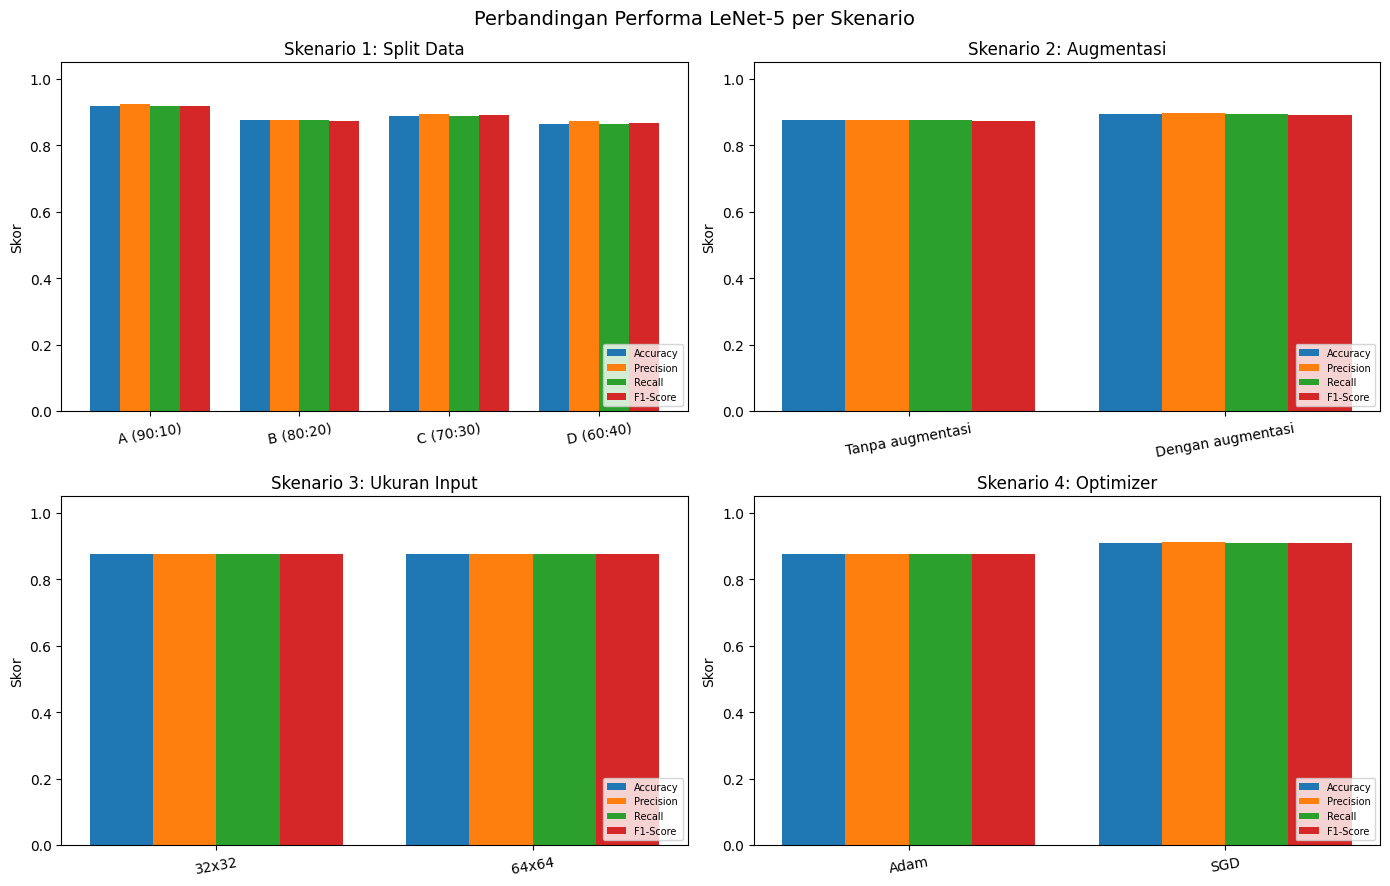

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, sc in zip(axes.ravel(), SCENARIOS):
    sub = df_summary[df_summary["Skenario"] == sc["name"]]
    x = np.arange(len(sub)); width = 0.2
    for i, m in enumerate(metrics):
        ax.bar(x + i * width, sub[m], width, label=m)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(sub["Model"], rotation=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Skor")
    ax.set_title(sc["name"])
    ax.legend(fontsize=7, loc="lower right")
fig.suptitle("Perbandingan Performa LeNet-5 per Skenario", fontsize=14)
fig.tight_layout()
plt.savefig("perbandingan_metrik_per_skenario.png", dpi=150)
plt.show()


### Perbandingan Accuracy Seluruh Model

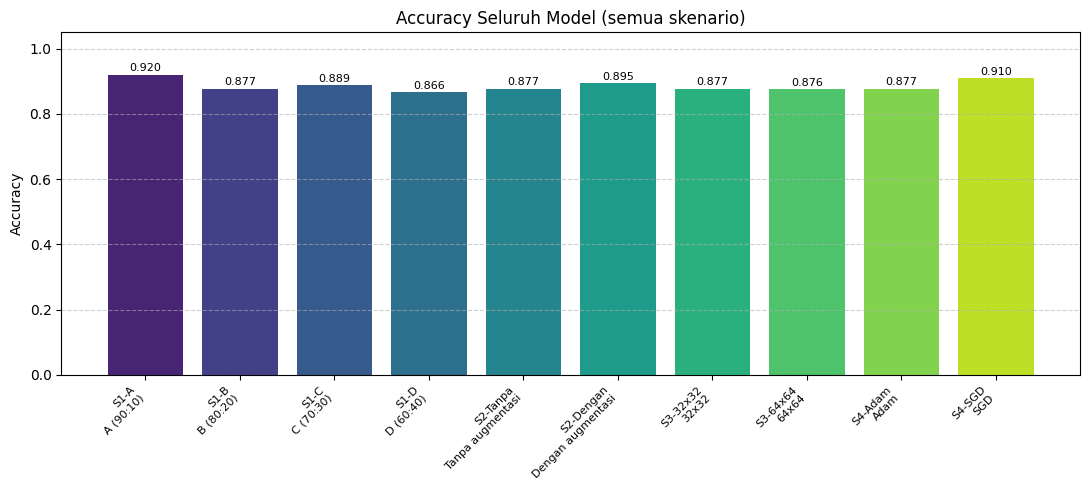

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
labels = df_summary["ID"] + "\n" + df_summary["Model"]
bars = ax.bar(labels, df_summary["Accuracy"], color=plt.cm.viridis(np.linspace(0.1, 0.9, len(df_summary))))
for b, v in zip(bars, df_summary["Accuracy"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Seluruh Model (semua skenario)")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()
plt.savefig("accuracy_semua_model.png", dpi=150)
plt.show()


## 9. Grafik Training Curve (Validation Accuracy & Loss) per Skenario

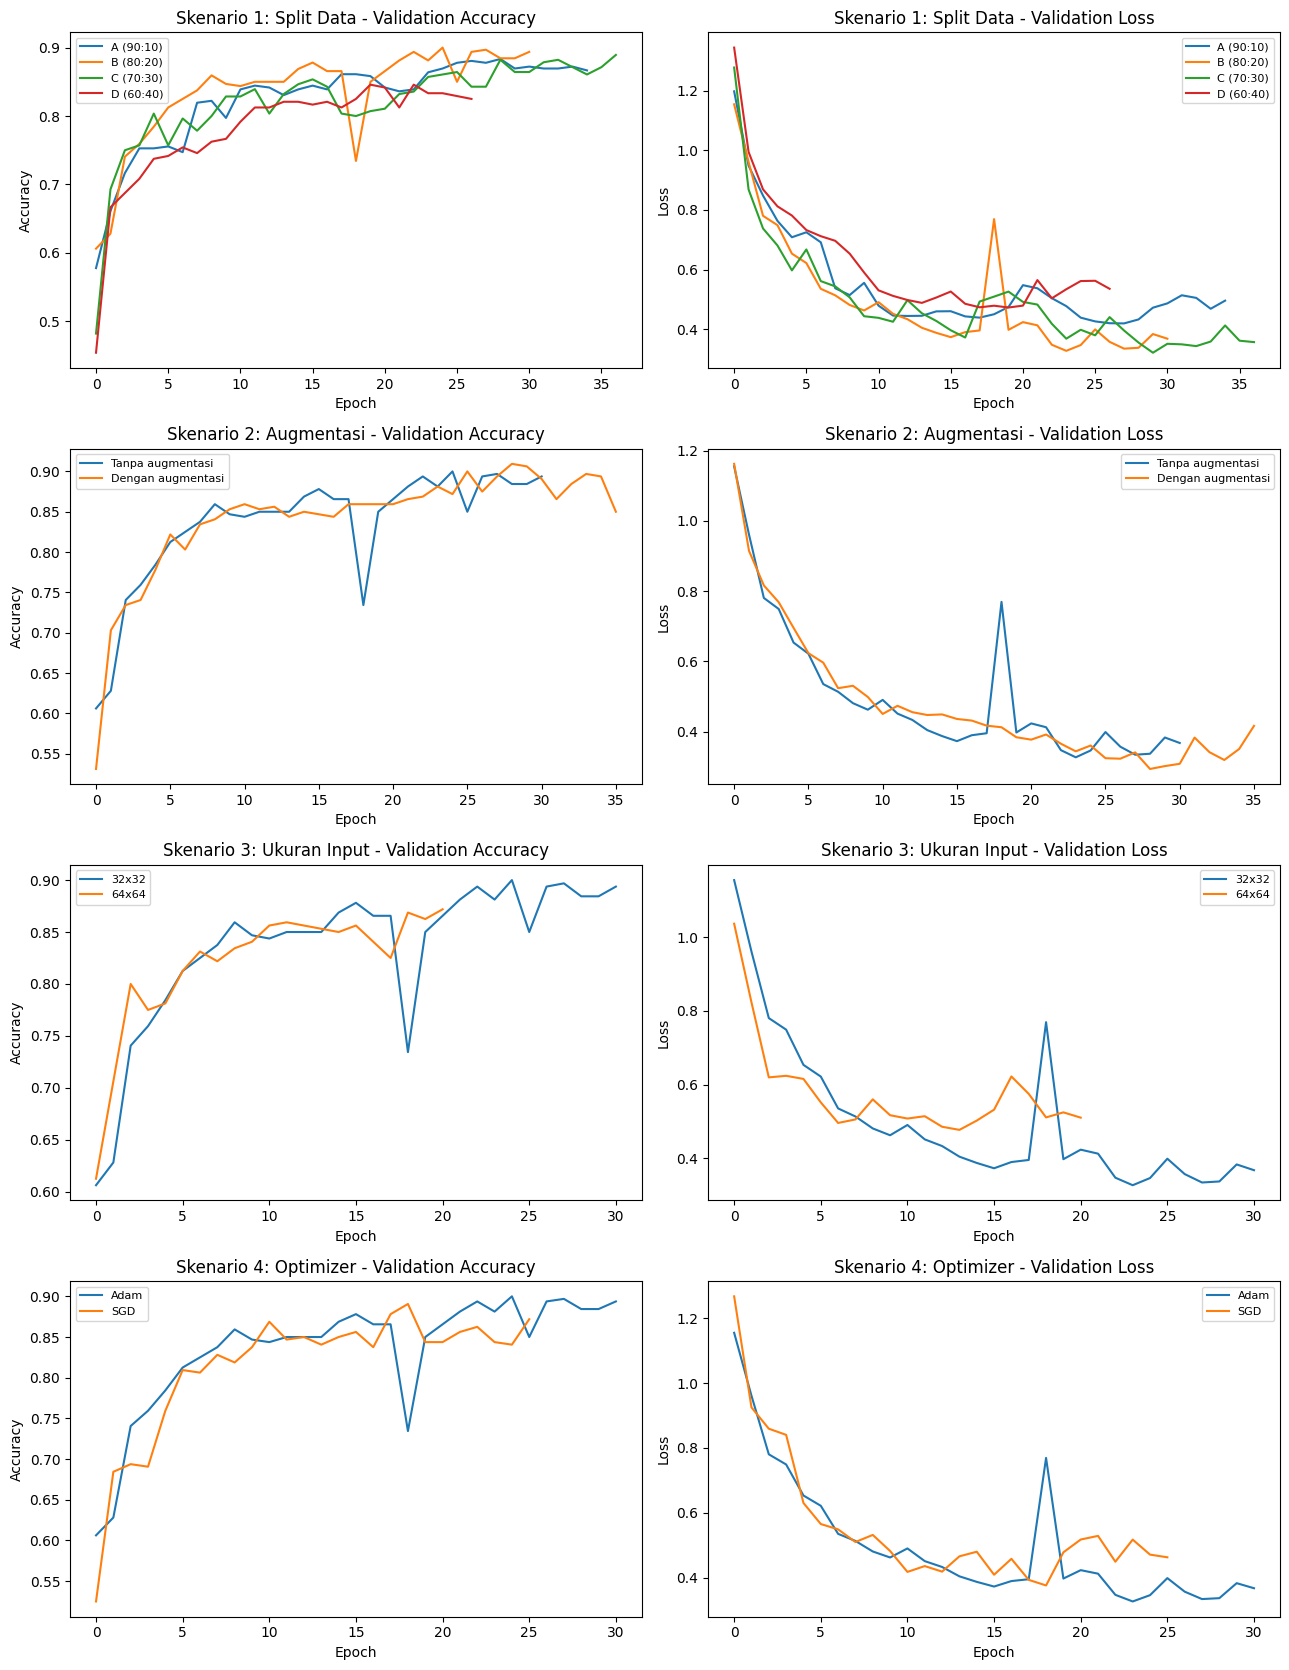

In [ ]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(13, 4.2 * len(SCENARIOS)))
for r, sc in enumerate(SCENARIOS):
    for m in sc["models"]:
        h = RESULTS[(sc["name"], m["label"])]["history"]
        axes[r, 0].plot(h["val_accuracy"], label=m["label"])
        axes[r, 1].plot(h["val_loss"], label=m["label"])
    axes[r, 0].set_title(f"{sc['name']} - Validation Accuracy")
    axes[r, 1].set_title(f"{sc['name']} - Validation Loss")
    for a in axes[r]:
        a.set_xlabel("Epoch"); a.legend(fontsize=8)
    axes[r, 0].set_ylabel("Accuracy"); axes[r, 1].set_ylabel("Loss")
fig.tight_layout()
plt.savefig("training_curves_per_skenario.png", dpi=150)
plt.show()


## Ringkasan Performa Terbaik

In [ ]:
print("Model terbaik di tiap skenario (berdasarkan Accuracy):\n")
best_per_sc = df_summary.loc[df_summary.groupby("Skenario")["Accuracy"].idxmax()]
print(best_per_sc[["Skenario", "Model", "Accuracy", "Precision", "Recall", "F1-Score"]].to_string(index=False))

print("\nModel terbaik dari seluruh skenario:")
print(df_summary.loc[df_summary["Accuracy"].idxmax()].to_string())


Model terbaik di tiap skenario (berdasarkan Accuracy):

                Skenario             Model  Accuracy  Precision  Recall  F1-Score
  Skenario 1: Split Data         A (90:10)    0.9200     0.9255  0.9200    0.9186
  Skenario 2: Augmentasi Dengan augmentasi    0.8950     0.8977  0.8950    0.8924
Skenario 3: Ukuran Input             32x32    0.8775     0.8759  0.8775    0.8747
   Skenario 4: Optimizer               SGD    0.9100     0.9120  0.9100    0.9089

Model terbaik dari seluruh skenario:
Skenario            Skenario 1: Split Data
Model                            A (90:10)
ID                                    S1-A
Split Train:Test                     90:10
Augmentasi                           Tidak
Input                                32x32
Optimizer                             ADAM
Data Latih                            3240
Data Validasi                          360
Data Uji                               400
Accuracy                              0.92
Precision              

## 10. Confusion Matrix per Model

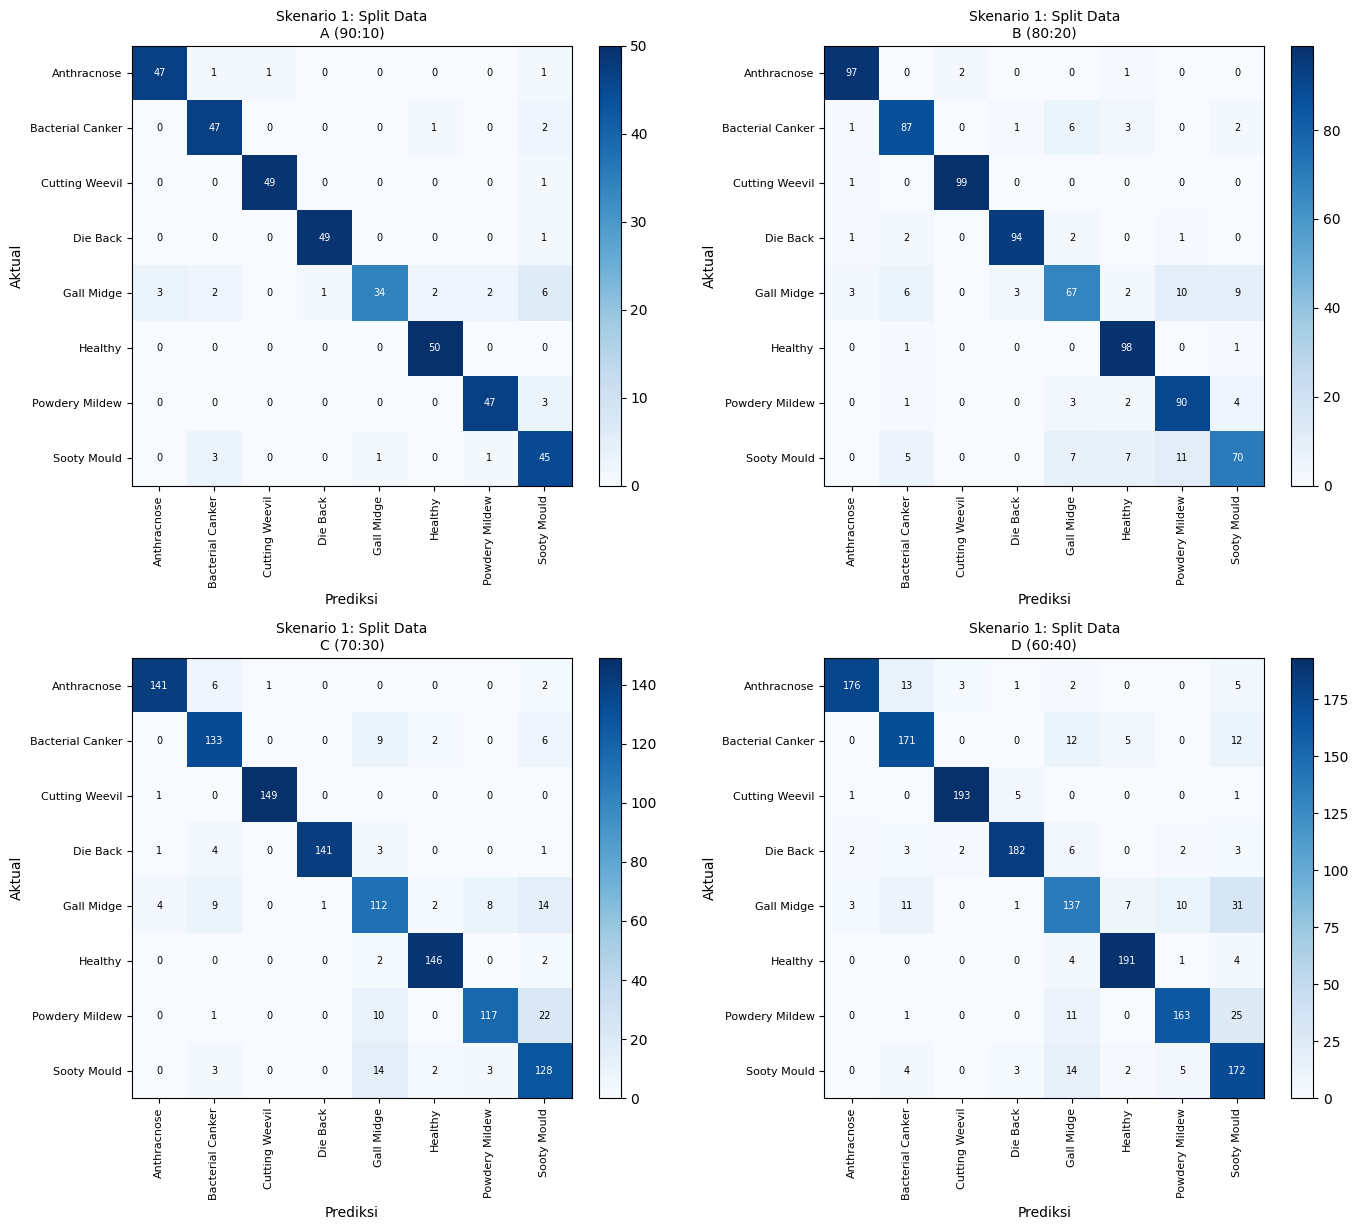

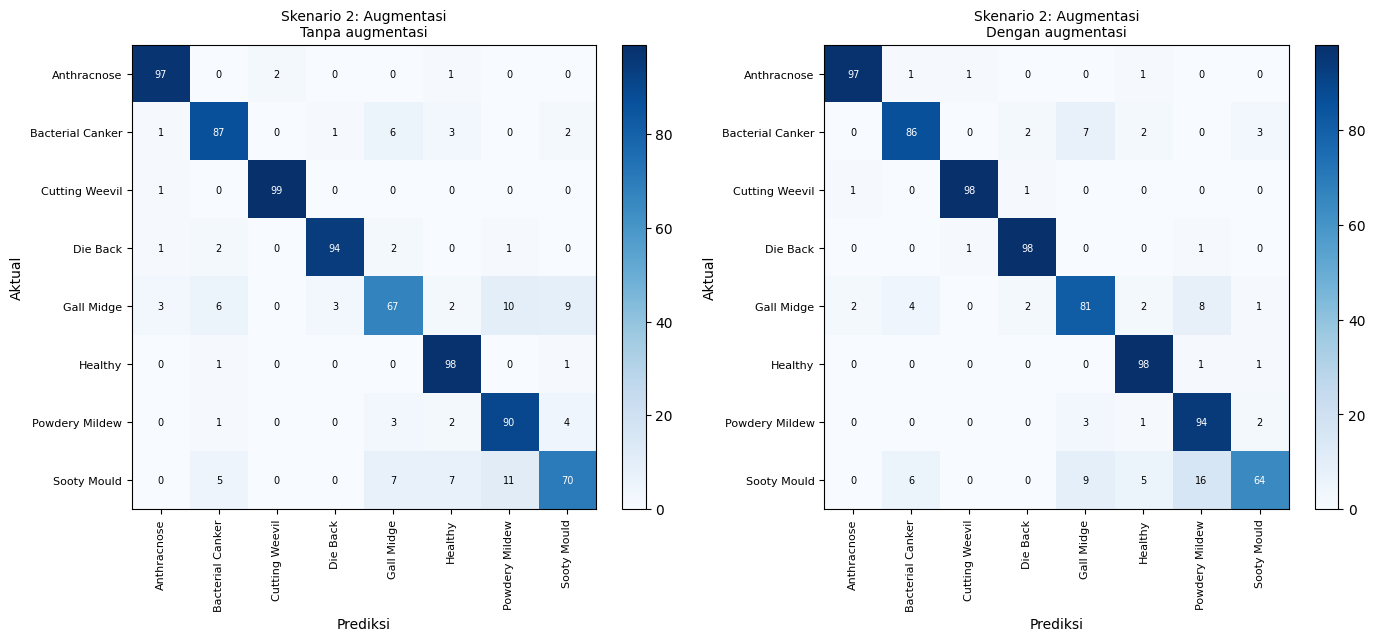

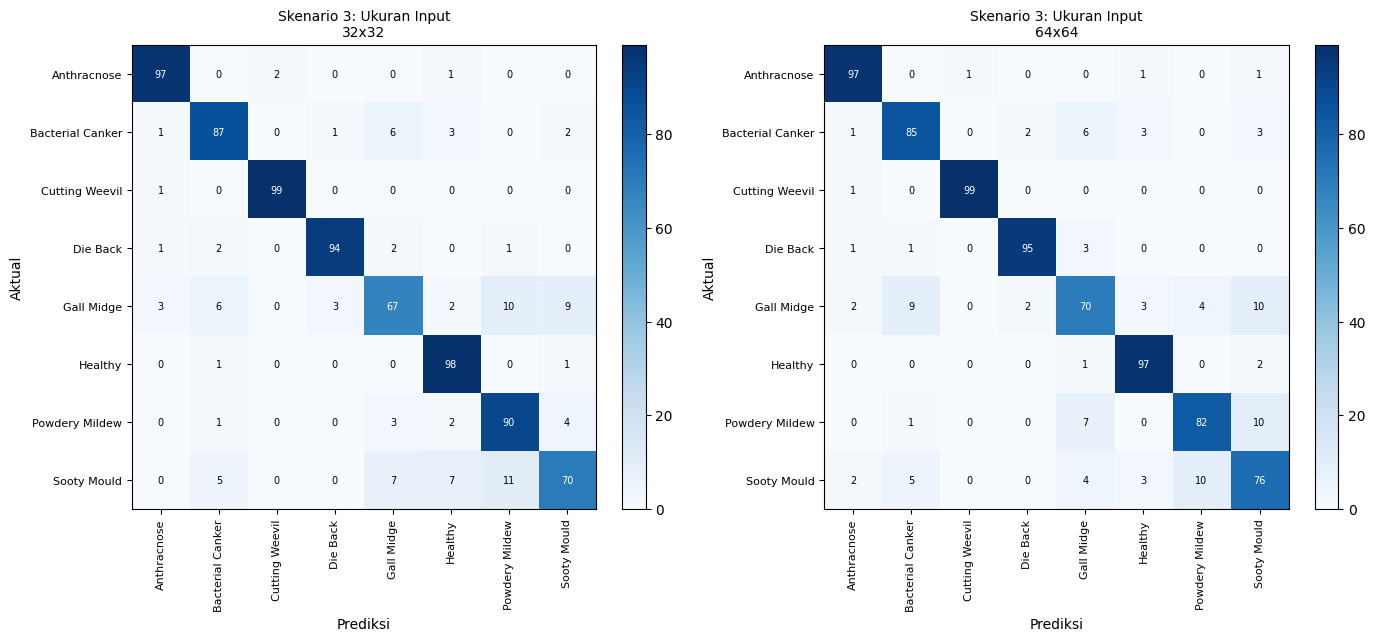

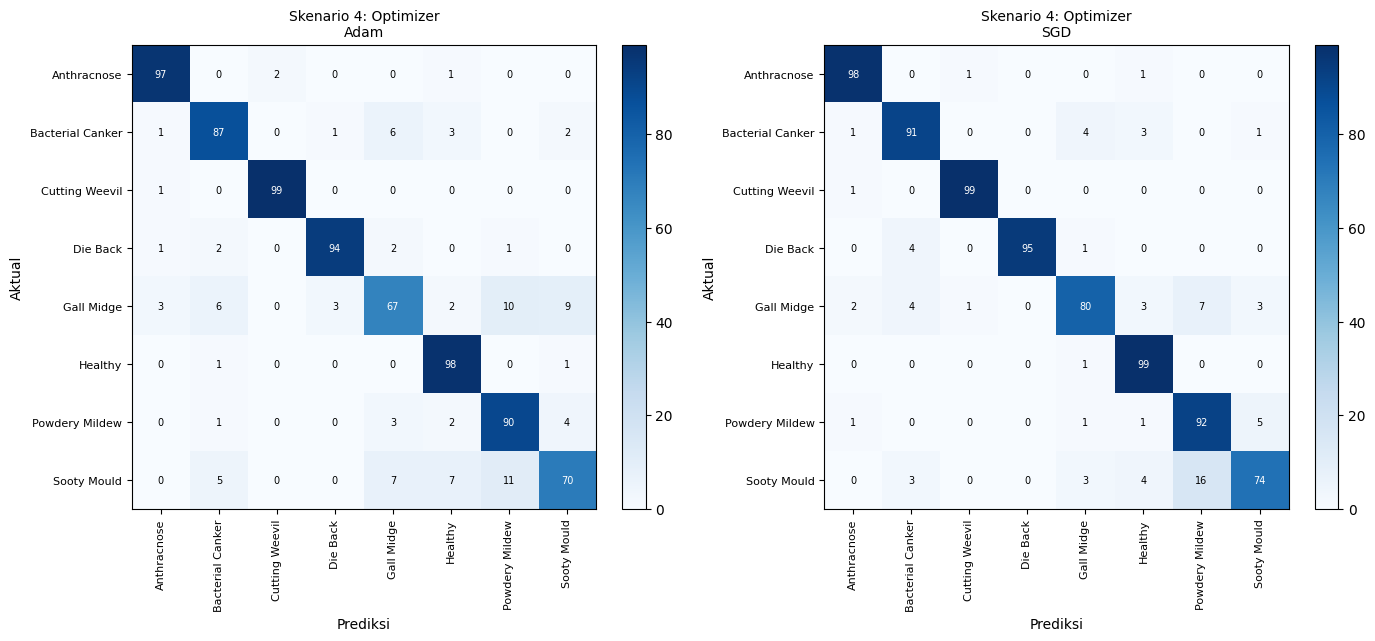

In [ ]:
import math

for sc in SCENARIOS:
    n = len(sc["models"])
    ncols = min(n, 2); nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, sc["models"]):
        cm = RESULTS[(sc["name"], m["label"])]["cm"]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{sc['name']}\n{m['label']}", fontsize=10)
        ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
        ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=90, fontsize=8); ax.set_yticklabels(classes, fontsize=8)
        for i in range(len(classes)):
            for j in range(len(classes)):
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        fig.colorbar(im, ax=ax, fraction=0.046)
    for ax in axes[n:]:
        ax.axis("off")
    fig.tight_layout()
    safe = sc["name"].split(":")[0].replace(" ", "_")
    plt.savefig(f"confusion_matrix_{safe}.png", dpi=150)
    plt.show()


## 11. Classification Report Lengkap per Model

In [ ]:
for (sc_name, label), res in RESULTS.items():
    print("=" * 70)
    print(f"{sc_name} | {label}")
    print("=" * 70)
    print(res["report"])


Skenario 1: Split Data | A (90:10)
                  precision    recall  f1-score   support

     Anthracnose       0.94      0.94      0.94        50
Bacterial Canker       0.89      0.94      0.91        50
  Cutting Weevil       0.98      0.98      0.98        50
        Die Back       0.98      0.98      0.98        50
      Gall Midge       0.97      0.68      0.80        50
         Healthy       0.94      1.00      0.97        50
  Powdery Mildew       0.94      0.94      0.94        50
     Sooty Mould       0.76      0.90      0.83        50

        accuracy                           0.92       400
       macro avg       0.93      0.92      0.92       400
    weighted avg       0.93      0.92      0.92       400

Skenario 1: Split Data | B (80:20)
                  precision    recall  f1-score   support

     Anthracnose       0.94      0.97      0.96       100
Bacterial Canker       0.85      0.87      0.86       100
  Cutting Weevil       0.98      0.99      0.99       10

## 12. Kesimpulan

> **Isi bagian ini setelah semua cell dijalankan**, berdasarkan tabel di bagian 7 dan grafik di bagian 8–10.
> Jangan menyalin angka dari notebook versi lama, karena skenarionya sudah berbeda.

Poin yang bisa dibahas per skenario:

1. **Skenario 1 (Split Data):** bagaimana accuracy berubah dari 90:10 sampai 60:40? Data latih yang lebih sedikit biasanya menurunkan performa, tetapi data uji yang lebih banyak membuat evaluasi lebih representatif. Ingat bahwa jumlah data uji berbeda di tiap model.
2. **Skenario 2 (Augmentasi):** apakah accuracy naik? Bandingkan juga selisih training vs validation accuracy untuk melihat apakah overfitting berkurang.
3. **Skenario 3 (Ukuran Input):** apakah 64x64 lebih baik daripada 32x32? Pertimbangkan juga biaya komputasi (jumlah parameter dan waktu training) dan jumlah epoch yang dibutuhkan.
4. **Skenario 4 (Optimizer):** bandingkan Adam vs SGD dari sisi accuracy dan kecepatan konvergensi (lihat kurva validation loss).
5. **Kelas yang sulit:** dari classification report dan confusion matrix, kelas mana yang paling sering salah diklasifikasikan, dan apa kemungkinan penyebabnya (kemiripan visual antar penyakit).
6. **Model terbaik keseluruhan:** sebutkan model dengan accuracy/F1 tertinggi. Hati-hati bila selisih antar model sangat kecil, karena tiap model hanya dilatih satu kali dengan satu seed.
